# Supervised ML(Regression)

**Goal:** 
Build a regression model to predict house prices based on features such as income, house age, rooms, population, etc.

In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

# Load California Housing dataset
data = fetch_california_housing(as_frame=True)

# View data set information 
print(data.DESCR)


.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [2]:
# Convert to pandas DataFrame
house_data = data.frame

#View your data
house_data.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


# Data Preprocessing

In [3]:
# Check missing values and duplicates
print(house_data.isnull().sum())      

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [4]:
print("Duplicates:", house_data.duplicated().sum())

#if column is continuous--> median, categorical--> mode
# Drop duplicates (if any)
# df = df.drop_duplicates()

Duplicates: 0


# Exploratory Data Analysis (EDA)

In [5]:
house_data.describe() 

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [6]:
corr = house_data.corr()
corr
# [-1,-0.9) and (0.9,1]

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


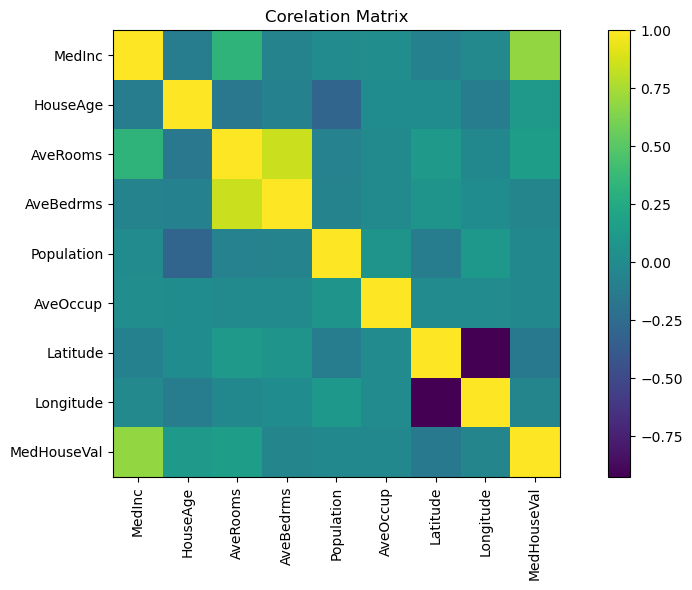

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.imshow(corr, cmap = 'viridis', interpolation= 'nearest')
plt.colorbar()
plt.title("Corelation Matrix")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.tight_layout()
plt.show()

# Feature Engineering

In [8]:
# We found that Longitude and Latitude are higly negative correalted,
# So we drop one of the column
house_data = house_data.drop(columns= ["Latitude"])

# Standardize the data

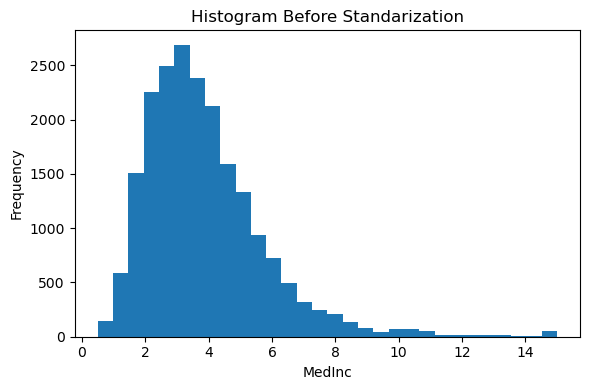

In [9]:
plt.figure(figsize= (6,4))
plt.hist(house_data["MedInc"],bins=30)
plt.title("Histogram Before Standarization")
plt.xlabel("MedInc")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [10]:
from sklearn.preprocessing import StandardScaler
x = house_data.iloc[:,:-1]
y = house_data['MedHouseVal']  
scaler = StandardScaler()
x_scaled= scaler.fit_transform(x)

In [11]:
x_scaled_df = pd.DataFrame(x_scaled, columns = x.columns)
x_scaled_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Longitude
0,2.344766,0.982143,0.628559,-0.153758,-0.974429,-0.049597,-1.327835
1,2.332238,-0.607019,0.327041,-0.263336,0.861439,-0.092512,-1.322844
2,1.782699,1.856182,1.155620,-0.049016,-0.820777,-0.025843,-1.332827
3,0.932968,1.856182,0.156966,-0.049833,-0.766028,-0.050329,-1.337818
4,-0.012881,1.856182,0.344711,-0.032906,-0.759847,-0.085616,-1.337818


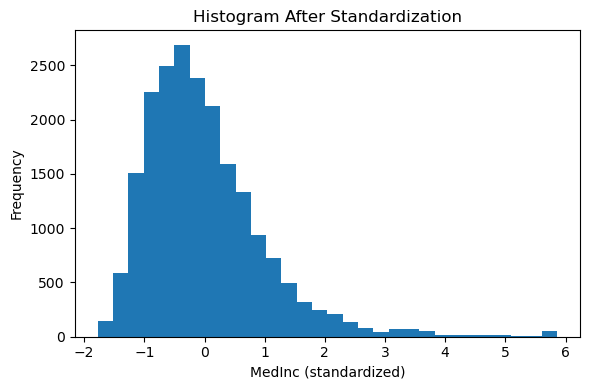

In [12]:
plt.figure(figsize=(6,4))
plt.hist(x_scaled_df["MedInc"],bins=30)
plt.title("Histogram After Standardization")
plt.xlabel("MedInc (standardized)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Split Dataset (Train/Test)

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42)

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Model Selection
LR = LinearRegression() 

In [15]:
# Model Training
LR.fit(X_train, y_train)

LinearRegression()

In [16]:
# Predict
y_pred = LR.predict(X_test)

# Weights (coefficients)
print("Weights (Coefficients):") # value of m
print(LR.coef_)

# Bias (Intercept)
print("Intercept:") # value of c
print(LR.intercept_)


Weights (Coefficients):
[ 1.04101772  0.20730022 -0.56598856  0.54006421  0.02888321 -0.04816339
 -0.04163588]
Intercept:
2.0681865733160345


In [17]:
# Model Evaluation
# Metrics
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = (mse)**0.5

# Adjusted R2
n = X_test.shape[0]
p = X_test.shape[1]
adj_r2 = 1 - (1-r2)*(n-1)/(n-p-1)

print("R2 Score:", r2)
print("Adjusted R2:", adj_r2)
print("MSE:", mse)
print("RMSE:", rmse)

R2 Score: 0.5102786640374892
Adjusted R2: 0.5094466132239608
MSE: 0.6417352354814021
RMSE: 0.8010837880530364


In [18]:
from sklearn.preprocessing import PolynomialFeatures  # y= m1x+m2x^2+.....+c

# Create polynomial features
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X_train)

# Train polynomial regression
model = LinearRegression()
model.fit(X_poly, y_train)

# Predict on transformed test set
X_test_poly = poly.transform(X_test)
y_pred = model.predict(X_test_poly)

# Metrics
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse =(mse)**0.5

# Adjusted R2
n = X_test.shape[0]
p = X_test_poly.shape[1]
adj_r2 = 1 - (1-r2)*(n-1)/(n-p-1)

print("R2 Score:", r2)
print("Adjusted R2:", adj_r2)
print("MSE:", mse)
print("RMSE:", rmse)

R2 Score: 0.5694609911127253
Adjusted R2: 0.5656723320269414
MSE: 0.5641821827288231
RMSE: 0.751120617962803


In [19]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Model
dt = DecisionTreeRegressor(
    criterion="squared_error",
    max_depth=5,
    random_state=42
)

# Train
dt.fit(X_train, y_train)

# Predict
y_pred_dt = dt.predict(X_test)

# Metrics
r2_dt = r2_score(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = mse_dt ** 0.5

# Adjusted R2
n = X_test.shape[0]
p = X_test.shape[1]
adj_r2_dt = 1 - (1 - r2_dt) * (n - 1) / (n - p - 1)

print("Decision Tree Regressor")
print("R2:", r2_dt)
print("Adjusted R2:", adj_r2_dt)
print("MSE:", mse_dt)
print("RMSE:", rmse_dt)


Decision Tree Regressor
R2: 0.5938383060160954
Adjusted R2: 0.5931482254680646
MSE: 0.5322379304140413
RMSE: 0.7295463867459295


In [20]:
from sklearn.ensemble import RandomForestRegressor

# Model
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=7,
    random_state=42
)

# Train
rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)

# Metrics
r2_rf = r2_score(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = mse_rf ** 0.5

# Adjusted R2
n = X_test.shape[0]
p = X_test.shape[1]
adj_r2_rf = 1 - (1 - r2_rf) * (n - 1) / (n - p - 1)

print("\nRandom Forest Regressor")
print("R2:", r2_rf)
print("Adjusted R2:", adj_r2_rf)
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)



Random Forest Regressor
R2: 0.6736056934798373
Adjusted R2: 0.6730511400464293
MSE: 0.4277100297107333
RMSE: 0.6539954355427363


In [21]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model
svr = SVR(
    kernel='rbf',
    C=100,
    gamma='scale',
    epsilon=0.1
)

# Train
svr.fit(X_train_scaled, y_train)

# Predict
y_pred_svr = svr.predict(X_test_scaled)

# Metrics
r2_svr = r2_score(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
rmse_svr = mse_svr ** 0.5

# Adjusted R2
n = X_test.shape[0]
p = X_test.shape[1]
adj_r2_svr = 1 - (1 - r2_svr) * (n - 1) / (n - p - 1)

print("\nSupport Vector Regressor")
print("R2:", r2_svr)
print("Adjusted R2:", adj_r2_svr)
print("MSE:", mse_svr)
print("RMSE:", rmse_svr)



Support Vector Regressor
R2: 0.6947598290262842
Adjusted R2: 0.6942412170853094
MSE: 0.39998946056374435
RMSE: 0.6324471998228345


In [22]:
# Here SVM has performed better than others
# Now we check for overfitting, therefore we check behaviour over training set
y_train_pred_svr = svr.predict(X_train_scaled)

# Metrics
r2_train_svr = r2_score(y_train, y_train_pred_svr)

print("\nSupport Vector Regressor")
print("R2:", r2_train_svr)


Support Vector Regressor
R2: 0.7425663427766266


In [25]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error

# Ridge model
ridge = Ridge(alpha=1.0)

# Train
ridge.fit(X_train, y_train)

# Predict
y_pred_ridge = ridge.predict(X_test)

# Metrics
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression")
print("R2:", r2_ridge)


Ridge Regression
R2: 0.5103207014127924


In [26]:
from sklearn.linear_model import Lasso

# Lasso model
lasso = Lasso(alpha=0.01)

# Train
lasso.fit(X_train, y_train)

# Predict
y_pred_lasso = lasso.predict(X_test)

# Metrics
r2_lasso = r2_score(y_test, y_pred_lasso)

print("\nLasso Regression")
print("R2:", r2_lasso)



Lasso Regression
R2: 0.5164507316335611
